In [1]:
#!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys
import os

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import numerical_utils as nuti

#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF
import update_config as uc
#local utils.py
import utils as U 



# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Extra for analysis and 'loggy' levels
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors


# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers
import importlib
from pathlib import Path

# Constants
grav=Co.grav()
cp=Co.cpair()

importlib.reload(U)


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
 a path to /glade/work/juliob added in Utils.numerical_utils 


<module 'utils' from '/glade/work/juliob/HiRes_ana_dev/Drivers/Analysis/utils.py'>

In [2]:
%%time

#date_tag = f"{year:04}-{month:02}-*"


f=f'/glade/derecho/scratch/juliob/archive/test_fgf/atm/regridded/test_fgf.cam.h2i.1985-07-01-00000.nc'
#f=f'/glade/derecho/scratch/juliob/archive/test_fgf/atm/regridded/test_fgf.cam.h2i.1985-01-15-00000.nc'

f='/glade/derecho/scratch/juliob/archive/GW_UnitTest/xy-testfrontg-2/xy-testfrontg-2.h.2004-07-*.nc'




ncdata='/glade/derecho/scratch/juliob/archive/test_fgf/atm/regridded/test_fgf.cam.h2i.1985-07-15-00000.nc'
f='/glade/derecho/scratch/juliob/archive/GW_UnitTest/xy-frontal-04/xy-frontal-04.h.1985-07-15-00000.nc'
 


print( f )
X=xr.open_mfdataset( f ,data_vars='different', coords='different' , compat='no_conflicts' )
Xnc=xr.open_mfdataset( ncdata ,data_vars='different', coords='different' , compat='no_conflicts' )








ny = X.sizes["ny"]
nx = X.sizes["nx"]

j = np.arange(ny).repeat(nx)
i = np.tile(np.arange(nx), ny)

X2 = (
    X.assign_coords(_j=("ncol", j), _i=("ncol", i))     # mapping ncol -> (j,i)
     .set_index(ncol=("_j", "_i"))
     .unstack("ncol")
     .rename({"_j": "ny", "_i": "nx"})
     .assign_coords(ny=X["lat_R"], nx=X["lon_R"])        # put real coords on axes
)


X2['lat']=X['lat_R']
X2['lon']=X['lon_R']
X=X2

/glade/derecho/scratch/juliob/archive/GW_UnitTest/xy-frontal-04/xy-frontal-04.h.1985-07-15-00000.nc
CPU times: user 1.28 s, sys: 560 ms, total: 1.84 s
Wall time: 3.09 s


In [3]:
X

<xarray.Dataset> Size: 540MB
Dimensions:          (ny: 192, nx: 288, level: 93, ilevel: 94, time: 1)
Coordinates:
  * ny               (ny) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * nx               (nx) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * time             (time) float64 8B 1.985e+07
Dimensions without coordinates: level, ilevel
Data variables: (12/43)
    lat_R            (ny) float64 2kB dask.array<chunksize=(192,), meta=np.ndarray>
    lon_R            (nx) float64 2kB dask.array<chunksize=(288,), meta=np.ndarray>
    hyam             (level) float32 372B dask.array<chunksize=(93,), meta=np.ndarray>
    hybm             (level) float32 372B dask.array<chunksize=(93,), meta=np.ndarray>
    hyai             (ilevel) float32 376B dask.array<chunksize=(94,), meta=np.ndarray>
    hybi             (ilevel) float32 376B dask.array<chunksize=(94,), meta=np.ndarray>
    ...               ...
    TAU_MOVMTN       (time, ilevel, ny, nx) float32 21MB dask.array<chunksize=(1, 47, 96, 288), meta=np.ndarray>
    TAU_DIAG_MOVMTN  (time, ilevel, ny, nx) float32 21MB dask.array<chunksize=(1, 47, 96, 288), meta=np.ndarray>
    TAUE             (time, ilevel, ny, nx) float32 21MB dask.array<chunksize=(1, 47, 96, 288), meta=np.ndarray>
    TAUW             (time, ilevel, ny, nx) float32 21MB dask.array<chunksize=(1, 47, 96, 288), meta=np.ndarray>
    TAUN             (time, ilevel, ny, nx) float32 21MB dask.array<chunksize=(1, 47, 96, 288), meta=np.ndarray>
    TAUS             (time, ilevel, ny, nx) float32 21MB dask.array<chunksize=(1, 47, 96, 288), meta=np.ndarray>
Attributes:
    ncdata:            /glade/derecho/scratch/juliob/archive/test_fgf/atm/reg...
    calculation_type:  xy
    Conventions:       CF-1.8

In [4]:
Xnc

<xarray.Dataset> Size: 269MB
Dimensions:  (time: 1, ilev: 94, lev: 93, lat: 192, lon: 288, slon: 287,
              slat: 191, nbnd: 2)
Coordinates:
  * time     (time) object 8B 1985-07-15 00:00:00
  * ilev     (ilev) float64 752B 0.004259 0.01201 0.02467 ... 987.4 995.1 1e+03
  * lev      (lev) float64 744B 0.008135 0.01834 0.03482 ... 983.2 991.2 997.5
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * slon     (slon) float64 2kB 0.625 1.875 3.125 4.375 ... 355.6 356.9 358.1
  * slat     (slat) float64 2kB -89.53 -88.59 -87.64 -86.7 ... 87.64 88.59 89.53
  * nbnd     (nbnd) int64 16B 0 1
Data variables: (12/21)
    date     (time) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    datesec  (time) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    hyai     (ilev) float64 752B dask.array<chunksize=(94,), meta=np.ndarray>
    hybi     (ilev) float64 752B dask.array<chunksize=(94,), meta=np.ndarray>
    hyam     (lev) float64 744B dask.array<chunksize=(93,), meta=np.ndarray>
    hybm     (lev) float64 744B dask.array<chunksize=(93,), meta=np.ndarray>
    ...       ...
    TAUE     (time, ilev, lat, lon) float32 21MB dask.array<chunksize=(1, 47, 96, 144), meta=np.ndarray>
    TAUW     (time, ilev, lat, lon) float32 21MB dask.array<chunksize=(1, 47, 96, 144), meta=np.ndarray>
    TAUN     (time, ilev, lat, lon) float32 21MB dask.array<chunksize=(1, 47, 96, 144), meta=np.ndarray>
    TAUS     (time, ilev, lat, lon) float32 21MB dask.array<chunksize=(1, 47, 96, 144), meta=np.ndarray>
    FRONTGF  (time, lev, lat, lon) float32 21MB dask.array<chunksize=(1, 47, 96, 144), meta=np.ndarray>
    PS       (time, lat, lon) float32 221kB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>

In [5]:


lon=X.lon.values
lat=X.lat.values

Lon,Lat=np.meshgrid(lon,lat)


ftopo='/glade/work/juliob/Topo/NCARTopoJTB/cases/fv1x1_Sco100_GrnlAnt/output/fv1x1_gmted2010_modis_bedmachine_nc3000_Laplace0100_noleak_greenlndantarcsgh30fac2.50_20251009.nc'
Topo=xr.open_dataset( ftopo )

hs = Topo.PHIS.values/grav
sgh = Topo.SGH.values
sgh30 = Topo.SGH30.values

In [6]:
%%time

te=X.T.values 
u=X.U.values
v=X.V.values
fgf0 =X.FRONTGF.values
#thx0 =X.FRONTGF.values
#thy0 =X.FRONTGA.values
th0 = X.TH.values

pmid=X.PMID.values

th2=te * (100_000./pmid) ** (2./7.)

z3e,z3o = U.geopht(X,topo=hs)
zeta=U.vorticity(X)

dse=grav*z3o + cp*te
th = dse/cp

grd2se = U.grad2_of_dse( dse, lon,lat )
fgf,thx,thy,ux,uy,vx,vy = U.fronto_horz( u, v, th2, lon,lat )


am  (93,)
ps  (1, 192, 288)
(1, 93, 192, 288)
CPU times: user 293 ms, sys: 312 ms, total: 604 ms
Wall time: 1.5 s


NameError: name 'thy0' is not defined

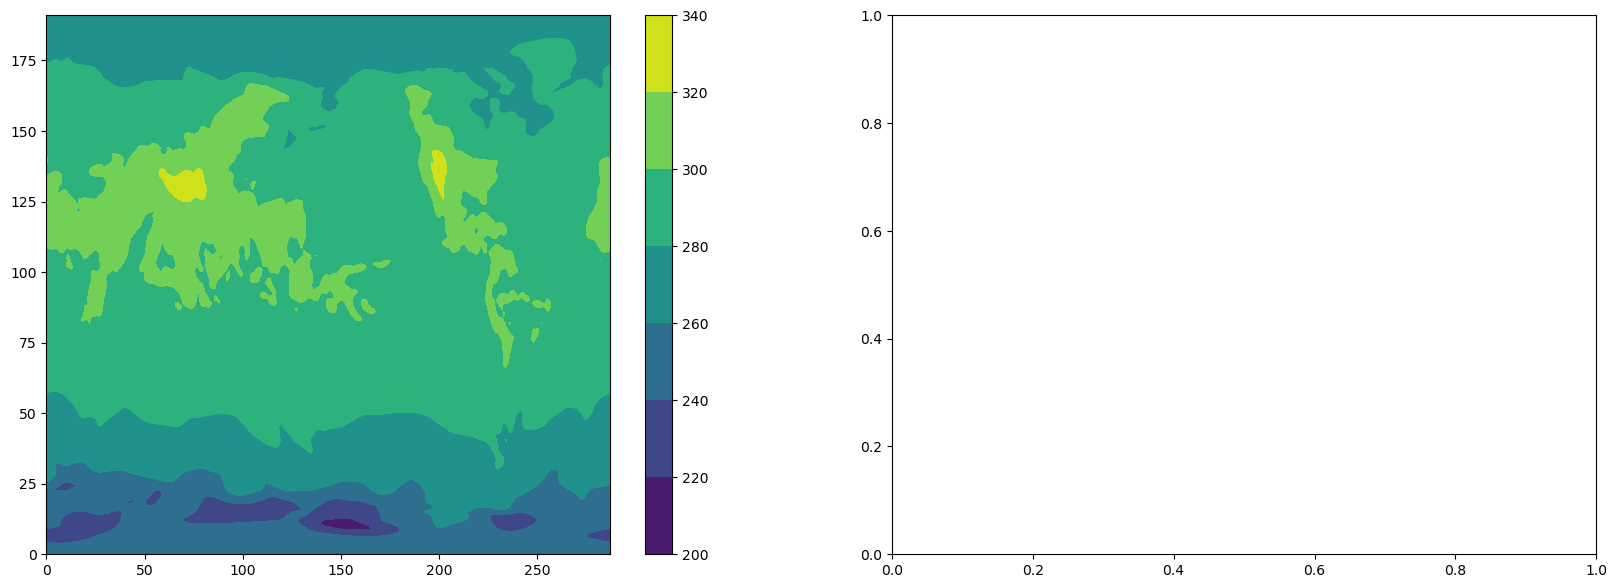

In [7]:
fig,axs=plt.subplots( 1,2,figsize=(20,7) )
ax=axs[0]
c=ax.contourf( th0[0,92,:,:] )
plt.colorbar(c)
ax=axs[1]
c=ax.contourf( thy0[0,92,:,:] )
plt.colorbar(c)


In [ ]:

plt.plot(th0[0,:,100,100] )
plt.plot(th[0,:,100,100] )


print( th[0,:,90,0] )


[1.0e-03 2.0e-03 5.0e-03 1.0e-02 1.5e-02 2.0e-02 3.0e-02 4.0e-02 5.0e-02
 6.0e-02 8.0e-02 1.0e-01 1.5e-01 2.0e-01 3.0e-01 4.0e-01 5.0e-01 6.0e-01
 1.0e+00 1.5e+00 2.0e+00 3.0e+00 4.0e+00 5.0e+00 6.0e+00 1.0e+01 1.5e+01
 2.0e+01 3.0e+01 4.0e+01 5.0e+01 6.0e+01]


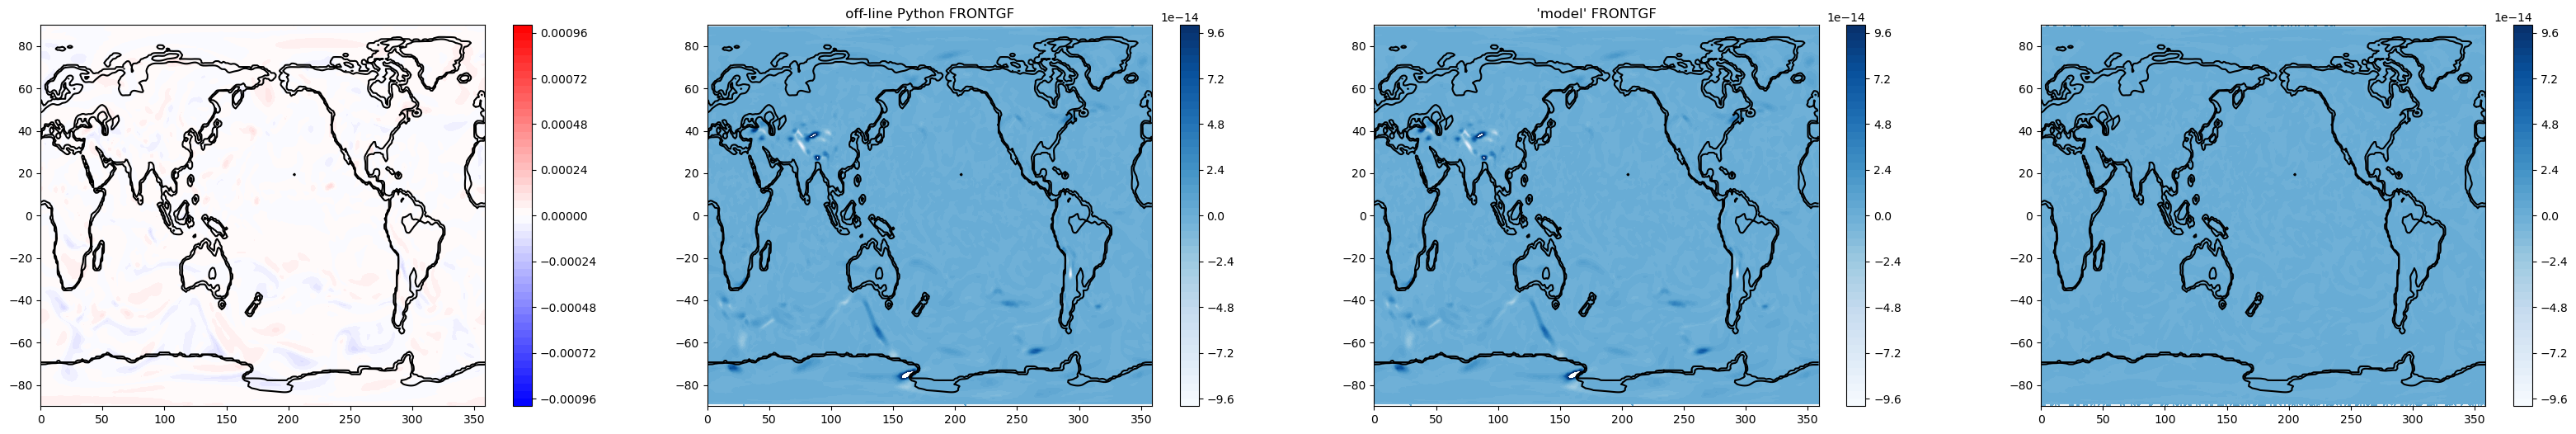

In [8]:
wavlev=40
srclev=70
t=0

flev=10.*np.asarray( [0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ] )
print(flev)
cmap_name='plasma' #'gist_ncar'


cmap = plt.cm.Blues #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 4, figsize=(40,6) )

ax=axs[0]
c=ax.contourf( lon,lat, zeta[t,srclev,:,:] ,  levels=np.linspace(-0.001,0.001,num=51), cmap='bwr') #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
ax=axs[1]
#c=ax.contourf( lon,lat, grd2se[15,srclev,:,:] , levels=np.linspace(0.,0.01,num=51), cmap=cmap) #levels=51)
c=ax.contourf( lon,lat, fgf[t,srclev,:,:] , levels=1.e-13*np.linspace(-1.,1.,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_title(" off-line Python FRONTGF ")
plt.colorbar(c)

ax=axs[2]
c=ax.contourf( lon,lat, fgf0[t,srclev,:,:] , levels=1.e-13*np.linspace(-1.,1.,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_title(" 'model' FRONTGF ")
plt.colorbar(c)

ax=axs[3]
c=ax.contourf( lon,lat, (fgf0-fgf)[t,srclev,:,:] , levels=1.e-13*np.linspace(-1.,1.,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)

#print( X.lev[srclev].values)


In [ ]:
X

In [ ]:
plt.plot( grd2se[15,srclev,40,:] )
plt.plot( 1000.* 1000.* dth2[15,srclev,40,:] )


In [ ]:
wavlev=20
srclev=75


flev=0.1*np.asarray( [0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ] )
print(flev)
cmap_name='plasma' #'gist_ncar'

cmap = plt.cm.Blues #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 4, figsize=(40,6) )
ax=axs[0]
c=ax.contourf( lon,lat, np.mean( epwp[:,wavlev,:,:],axis=0) , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
ax=axs[1]
c=ax.contourf( lon,lat, np.mean( zeta2[:,srclev,:,:], axis=0) , levels=np.linspace(0.,1e-8,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
ax=axs[2]
c=ax.contourf( lon,lat, 1000.*np.mean( grd2se[:,srclev,:,:], axis=0) , levels=np.linspace(0.,0.001,num=51), cmap=cmap) #levels=51)
#c=ax.contourf( lon,lat, np.mean( fgx[:,srclev,:,:], axis=0) , levels= 1.0e-8*np.linspace(-1.,1.,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
print( X.lev[srclev].values)
ax=axs[3]
c=ax.contourf( lon,lat, np.mean( tp2[:,srclev,:,:], axis=0) , levels=  np.linspace(0.,0.5,num=51)  , cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
print( X.lev[srclev].values)


In [ ]:
plt.plot( tp2[15,srclev,:,:] .flatten() )
print( X.time[15] )

In [ ]:
#Pick z level ...
z=35

ayx=epwp[:,z,:,:]
print ( ayx.shape)

zlev=-7.0*np.log( X.lev.values /1000. )


print( zlev[z] )

In [ ]:



flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ]
print(flev)
cmap_name='plasma' #'gist_ncar'

payx=np.average( ayx, axis=0 )

cmap = plt.cm.Blues #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 3, figsize=(30,6) )
ax=axs[0]
c=ax.contourf( lon,lat,np.mean( ayx, axis=0) , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
ax=axs[1]
c=ax.contourf( lat,zlev,np.mean( np.mean(epwp, axis=3) , axis=0) , levels=flev, cmap=cmap, norm=norm ) #levels=51)
plt.colorbar(c)

In [ ]:
#plt.contourf( ayx[:,30,:] ,levels=np.linspace(-.1,.1,num=51), cmap='bwr' )

#plt.contourf( ayx[:,30,:] ,levels=np.linspace(0,.01,num=51), cmap='bwr' )
#plt.contourf( ayx[:,40,:] ,levels=flev, cmap=cmap, norm=norm )

fig,axs = plt.subplots( 1 , 2, figsize=(15,7) )


ax=axs[0]
ax.contourf( ayx[:,40,:] ,levels=flev, cmap=cmap, norm=norm ) 
ax=axs[1]
ax.contour( zeta2[:,srclev,40,:] ,levels=21, cmap=cmap )
print(lat[40])


In [ ]:
nt,nz,ny,nx = np.shape(z3o)
Lon_zx=np.zeros( (nz,nx) )
for k in np.arange( nz ):
    Lon_zx[k,:]=lon[:]

In [ ]:
lat_zx=-42.
t,y=15,np.argmin( np.abs(lat-lat_zx ) )
print( y )
#plt.contourf( Lon_zx, z3o[t,:,y,:] , zeta2[t,:,y,:] )
#plt.contourf( Lon_zx, z3o[t,:,y,:] , grd2se[t,:,y,:] ,levels=np.linspace(0.,0.01,num=51), cmap=cmap)
#plt.ylim(0,20_000)

cmap = plt.cm.Blues #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

zrang=[0,20_000.]
fig,axs=plt.subplots( 1, 3, figsize=(30,6) )

ax=axs[0]
c=ax.contourf( Lon_zx, z3o[t,:,y,:] , epwp[t,:,y,:] , levels=flev, cmap=cmap, norm=norm ) #levels=51)
ax.set_ylim( zrang )
ax.plot( lon, z3e[t,nz,y,:] )
plt.colorbar( c )

ax=axs[1]
c=ax.contourf( Lon_zx, z3o[t,:,y,:] , zeta[t,:,y,:] , levels=np.linspace(-0.002,0.002,num=51), cmap='bwr' ) #levels=51)
ax.set_ylim( zrang )
plt.colorbar( c )


ax=axs[2]
c=ax.contourf( Lon_zx, z3o[t,:,y,:] , grd2se[t,:,y,:] , levels=np.linspace(0,0.01,num=51), cmap=cmap ) #levels=51)
ax.set_ylim( zrang )
plt.colorbar( c )




In [ ]:
plt.plot( np.mean( zeta2[:,srclev,:,:], axis=0).flatten() )

In [ ]:
bins=np.linspace(0.001,0.201,num=51)
h= np.histogram(ayx[:,30:50,0:100].flatten() , bins=bins)

In [ ]:
h

In [ ]:
plt.plot(h[1][0:-1],np.log(h[0]+0.1) )


In [ ]:
trunc_k, sigma=20, 2.
hs_sm = gaussian_filter(  hs , sigma=sigma,
                           truncate=((trunc_k-1)/2)/sigma, mode="nearest")

threshold=0.025 #1
#threshold=0.01 #1

#it, iy, ix = np.where( (ayx > threshold) & (hs_sm <0.1)) #(ayx > threshold)
#mask_int = ( (ayx > threshold) & (hs_sm <0.1)).astype(int)


#booleo= (ayx > threshold) & (hs_sm <0.1) & (Lat>40) & (Lat<70) # & (Lat<-35.) & (Lon<150.)
booleo= (ayx > threshold) & (hs_sm <0.1) & (Lat<-35.) #& (Lon<150.)
it, iy, ix = np.where( booleo) #(ayx > threshold)
mask_int = booleo.astype(int)


booleo_ctl= (ayx > 0.) & (hs_sm <0.1) & (Lat<-35.) #& (Lon<150.)
it_ctl, iy_ctl, ix_ctl = np.where( booleo_ctl) #(ayx > threshold)
mask_ctl_int = booleo_ctl.astype(int)


In [ ]:
nps=len(ix)
print( nps )


In [ ]:



flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ]
print(flev)
cmap='plasma' #'gist_ncar'

payx=np.average( ayx, axis=0 )
payx_mask=np.sum( ayx*mask_int, axis=0 )/(np.sum(mask_int, axis=0 ))

cmap = plt.cm.Blues #gist_ncar  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 3, figsize=(30,6) )
ax=axs[0]
c=ax.contourf( lon,lat,payx , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)

ax=axs[1]
c=ax.contourf( lon,lat,payx_mask , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)



In [ ]:
%%time
u=X.U.values
#te=X.T.values

In [ ]:
u_gw=u[it,:,iy,ix]
u_ctl=u[it_ctl, :, iy_ctl, ix_ctl]


z3o_gw=z3o[it,:,iy,ix] 
z3o_ctl=z3o[it_ctl,:,iy_ctl,ix_ctl] 
dse_gw=dse[it,:,iy,ix] /cp
dse_ctl=dse[it_ctl,:,iy_ctl,ix_ctl] /cp
zeta_gw=zeta[it,:,iy,ix]
zeta_ctl=zeta[it_ctl,:,iy_ctl,ix_ctl]
grd2se_gw=grd2se[it,:,iy,ix] /cp
grd2se_ctl=grd2se[it_ctl,:,iy_ctl,ix_ctl] /cp


In [ ]:
fig,axs=plt.subplots(1,3, figsize=(30,6) )
ax=axs[0]
ax.plot(np.average(zeta_gw,axis=0) , np.average(z3o_gw,axis=0))
ax.plot(np.average(zeta_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.plot(  np.average(zeta_gw,axis=0) -  np.average(zeta_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.set_ylim(0,20_000)
ax=axs[1]
ax.plot(np.average(u_gw,axis=0) , np.average(z3o_gw,axis=0))
ax.plot(np.average(u_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.set_ylim(0,20_000)


In [ ]:
fig,axs=plt.subplots(1,3, figsize=(30,6) )
ax=axs[0]
ax.plot(np.average(grd2se_gw,axis=0) , np.average(z3o_gw,axis=0))
ax.plot(np.average(grd2se_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.plot(  np.average(grd2se_gw,axis=0) -  np.average(grd2se_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.set_ylim(0,20_000)


In [ ]:

plt.plot(np.average(dse_gw,axis=0))
plt.plot(np.average(dse_ctl,axis=0))
plt.ylim(280,340)

In [ ]:
print( X.lev.values[93-30-1])
print( X.lev.values[93-30+1])


In [ ]:



flev=np.linspace(-60,60,num=31) #21 0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
flev=np.linspace(-0.0005,0.0005,num=31) #21 0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
print(flev)
payx=np.average( uuu[:,60,:,:], axis=0 )
payx_mask=np.sum( uuu[:,60,:,:]*mask_int, axis=0 )/(np.sum(mask_int, axis=0 ))
payx=np.average( zeta[:,60,:,:], axis=0 )
payx_mask=np.sum( zeta[:,60,:,:]*mask_int, axis=0 )/(np.sum(mask_int, axis=0 ))


cmap = plt.cm.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 3, figsize=(30,6) )
ax=axs[0]
c=ax.contourf( payx , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( hs, levels=[1,100] ,colors='black')
plt.colorbar(c)

ax=axs[1]
c=ax.contourf( payx_mask , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( hs, levels=[1,100] ,colors='black')
plt.colorbar(c)



In [ ]:
epwp_zon=np.mean( np.mean( epwp, axis=3) ,axis=0)

In [ ]:
epwp_zon.shape

In [ ]:
plt.contour(epwp_zon )